<a href="https://colab.research.google.com/github/nandinisingh66/CSET343/blob/main/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install kagglehub seaborn scikit-learn statsmodels

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [ ]:
import kagglehub

path = kagglehub.dataset_download("jamaltariqcheema/pima-indians-diabetes-dataset")

print(path)

Using Colab cache for faster access to the 'pima-indians-diabetes-dataset' dataset.
/kaggle/input/pima-indians-diabetes-dataset


In [ ]:
files = glob.glob(path + "/**/*.csv", recursive=True)

print(files)

['/kaggle/input/pima-indians-diabetes-dataset/diabetes.csv']


In [ ]:
df = pd.read_csv(files[0])

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (768, 9)

Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

,0
Pregnancies,0.0
Glucose,0.0
BloodPressure,0.0
SkinThickness,0.0
Insulin,0.0
BMI,0.0
DiabetesPedigreeFunction,0.0
Age,0.0
Outcome,0.0


In [ ]:
medical_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

(df[medical_columns] == 0).sum()

,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


In [ ]:
df_clean = df.copy()

df_clean[medical_columns] = df_clean[medical_columns].replace(0, np.nan)

df_clean.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
for column in medical_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

df_clean.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [ ]:
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("New shape:", df_clean.shape)

New shape: (768, 9)


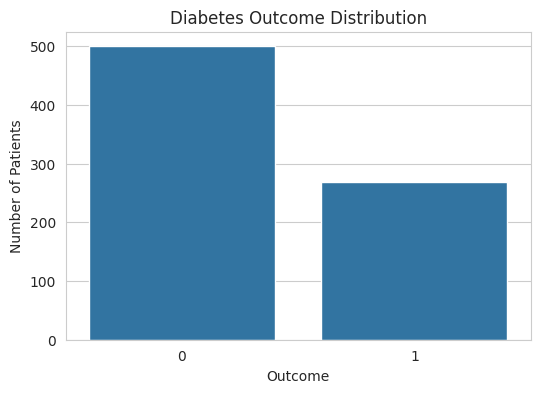

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df_clean, x="Outcome")

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.show()

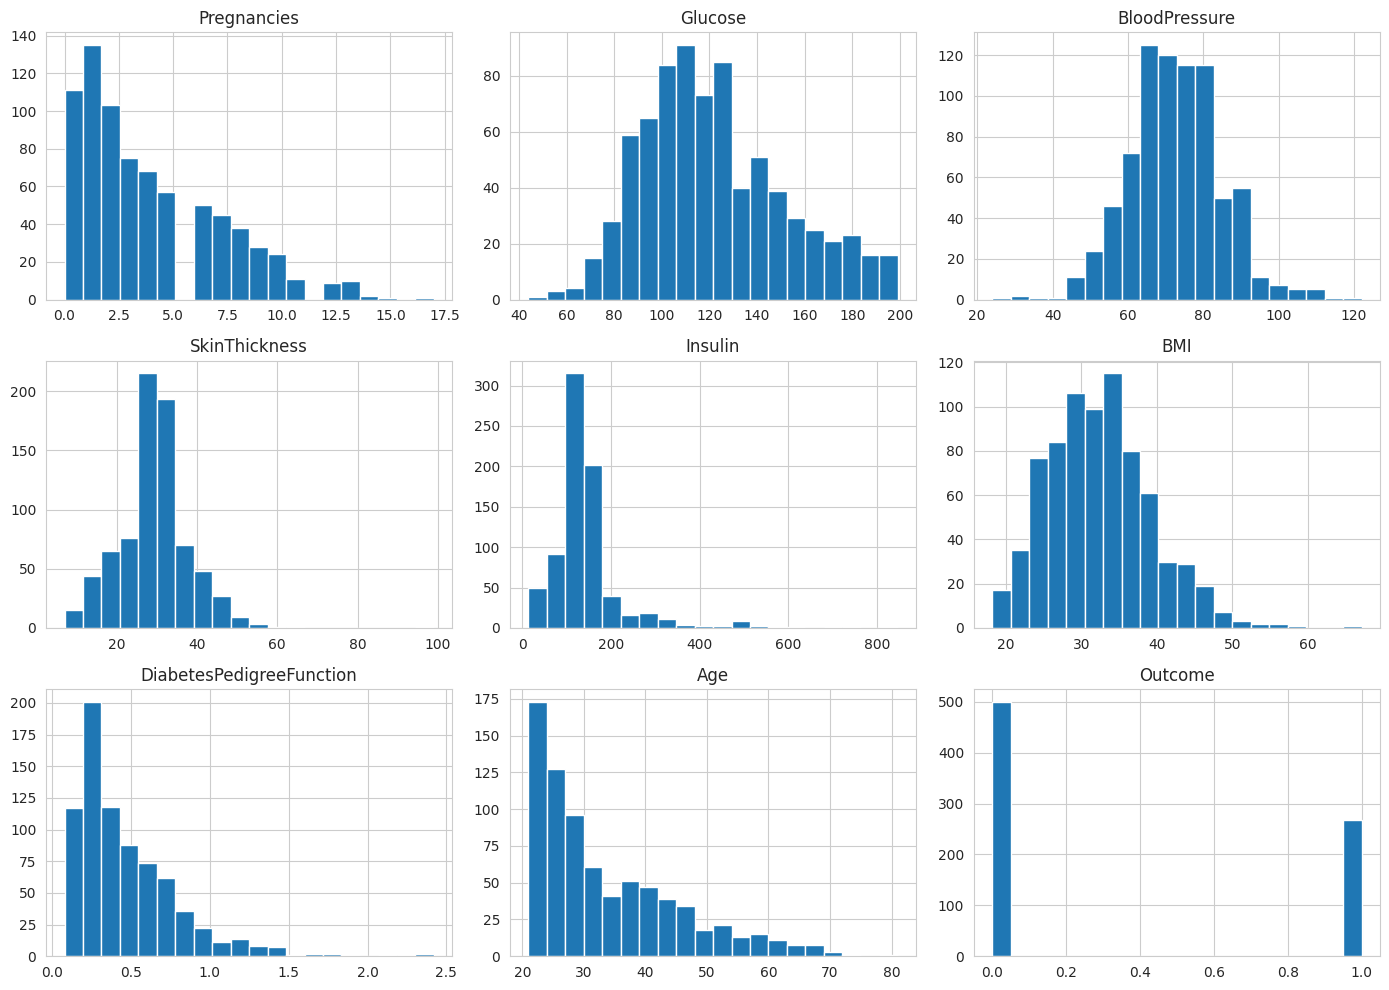

In [ ]:
df_clean.hist(figsize=(14,10), bins=20)

plt.tight_layout()
plt.show()

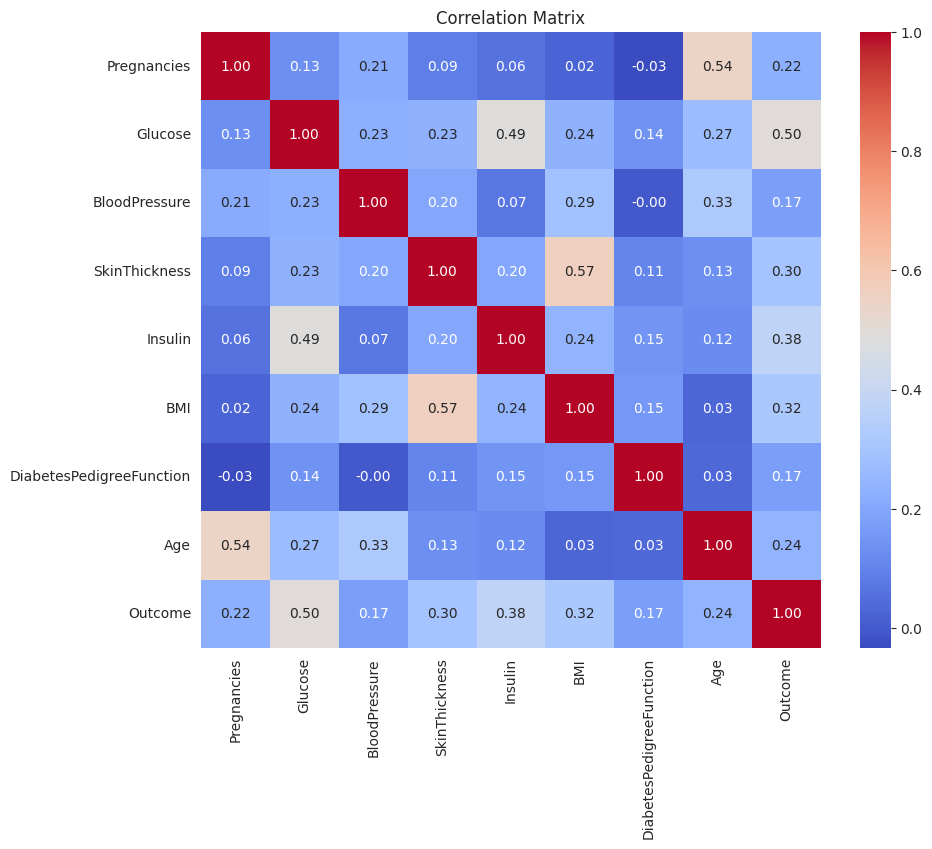

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_clean.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
df_clean["BMI_Category"] = pd.cut(
    df_clean["BMI"],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

df_clean[["BMI", "BMI_Category"]].head()

,BMI,BMI_Category
0,33.6,Obese
1,26.6,Overweight
2,23.3,Normal
3,28.1,Overweight
4,43.1,Obese


In [ ]:
contingency_table = pd.crosstab(
    df_clean["BMI_Category"],
    df_clean["Outcome"]
)

contingency_table

Outcome,0,1
BMI_Category,,
Underweight,4,0
Normal,101,7
Overweight,136,44
Obese,259,217


In [ ]:
diabetic = df_clean[df_clean["Outcome"] == 1]["Glucose"]
non_diabetic = df_clean[df_clean["Outcome"] == 0]["Glucose"]

t_statistic, p_value = stats.ttest_ind(
    diabetic,
    non_diabetic,
    equal_var=False
)

print("T-statistic:", t_statistic)
print("p-value:", p_value)

T-statistic: 14.992112521284485
p-value: 8.301766379086572e-42


In [ ]:
anova_data = df_clean[
    ["BMI_Category", "Glucose"]
].dropna()

groups = [
    group["Glucose"].values
    for _, group in anova_data.groupby("BMI_Category", observed=True)
]

f_statistic, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_statistic)
print("p-value:", p_value)

F-statistic: 13.500878158256349
p-value: 1.3657943712769507e-08


In [ ]:
X = df_clean.drop(columns=["Outcome", "BMI_Category"])
y = df_clean["Outcome"]

selector = SelectKBest(score_func=f_classif, k=5)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features.tolist())

Selected Features:
['Glucose', 'SkinThickness', 'Insulin', 'BMI', 'Age']


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.864625,-0.032180,0.665181,0.311604,0.169483,0.468492,1.425995
1,-0.844885,-1.204727,-0.528124,-0.010112,-0.440843,-0.848549,-0.365061,-0.190672
2,1.233880,2.014265,-0.693438,0.327535,0.311604,-1.328478,0.604397,-0.105584
3,-0.844885,-1.073339,-0.528124,-0.685405,-0.536303,-0.630399,-0.920763,-1.041549
4,-1.141852,0.503310,-2.677212,0.665181,0.294758,1.551096,5.484909,-0.020496


In [ ]:
!pip -q install nltk

In [ ]:
import re
import nltk
import pandas as pd
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
url = "https://raw.githubusercontent.com/salgadev/medical-nlp/master/data/mtsamples.csv"

text_df = pd.read_csv(url)

text_df.head()

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [ ]:
print("Shape:", text_df.shape)

print("\nColumns:")
print(text_df.columns.tolist())

Shape: (4999, 6)

Columns:
['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


In [ ]:
text_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB


In [ ]:
text_df.isnull().sum()


,0
Unnamed: 0,0
description,0
medical_specialty,0
sample_name,0
transcription,33
keywords,1068


In [ ]:
text_df.columns

Index(['Unnamed: 0', 'description', 'medical_specialty', 'sample_name',
       'transcription', 'keywords'],
      dtype='object')

In [ ]:
text_df = text_df.dropna(subset=["transcription"]).reset_index(drop=True)

print(text_df.shape)

(4966, 6)


In [ ]:
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'\b\d{10,}\b', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

text_df["cleaned_text"] = text_df["transcription"].apply(clean_text)

text_df[["transcription", "cleaned_text"]].head()

,transcription,cleaned_text
0,"SUBJECTIVE:, This 23-year-old white female pr...",subjective this year old white female presents...
1,"PAST MEDICAL HISTORY:, He has difficulty climb...",past medical history he has difficulty climbin...
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...",history of present illness i have seen abc tod...
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...",d m mode left atrial enlargement with left atr...
4,1. The left ventricular cavity size and wall ...,the left ventricular cavity size and wall thic...


In [ ]:
text_df["tokens"] = text_df["cleaned_text"].apply(word_tokenize)

text_df[["cleaned_text", "tokens"]].head()

,cleaned_text,tokens
0,subjective this year old white female presents...,"[subjective, this, year, old, white, female, p..."
1,past medical history he has difficulty climbin...,"[past, medical, history, he, has, difficulty, ..."
2,history of present illness i have seen abc tod...,"[history, of, present, illness, i, have, seen,..."
3,d m mode left atrial enlargement with left atr...,"[d, m, mode, left, atrial, enlargement, with, ..."
4,the left ventricular cavity size and wall thic...,"[the, left, ventricular, cavity, size, and, wa..."


In [ ]:
stop_words = set(stopwords.words("english"))

text_df["filtered_tokens"] = text_df["tokens"].apply(
    lambda tokens: [
        word for word in tokens
        if word not in stop_words
    ]
)

text_df[["tokens", "filtered_tokens"]].head()

,tokens,filtered_tokens
0,"[subjective, this, year, old, white, female, p...","[subjective, year, old, white, female, present..."
1,"[past, medical, history, he, has, difficulty, ...","[past, medical, history, difficulty, climbing,..."
2,"[history, of, present, illness, i, have, seen,...","[history, present, illness, seen, abc, today, ..."
3,"[d, m, mode, left, atrial, enlargement, with, ...","[mode, left, atrial, enlargement, left, atrial..."
4,"[the, left, ventricular, cavity, size, and, wa...","[left, ventricular, cavity, size, wall, thickn..."


In [ ]:
text_df["processed_text"] = text_df["filtered_tokens"].apply(
    lambda tokens: " ".join(tokens)
)

text_df[["processed_text"]].head()

,processed_text
0,subjective year old white female presents comp...
1,past medical history difficulty climbing stair...
2,history present illness seen abc today pleasan...
3,mode left atrial enlargement left atrial diame...
4,left ventricular cavity size wall thickness ap...


In [ ]:
text_df["medical_specialty"].value_counts().head(15)

,count
medical_specialty,
Surgery,1088
Consult - History and Phy.,516
Cardiovascular / Pulmonary,371
Orthopedic,355
Radiology,273
General Medicine,259
Gastroenterology,224
Neurology,223
SOAP / Chart / Progress Notes,166


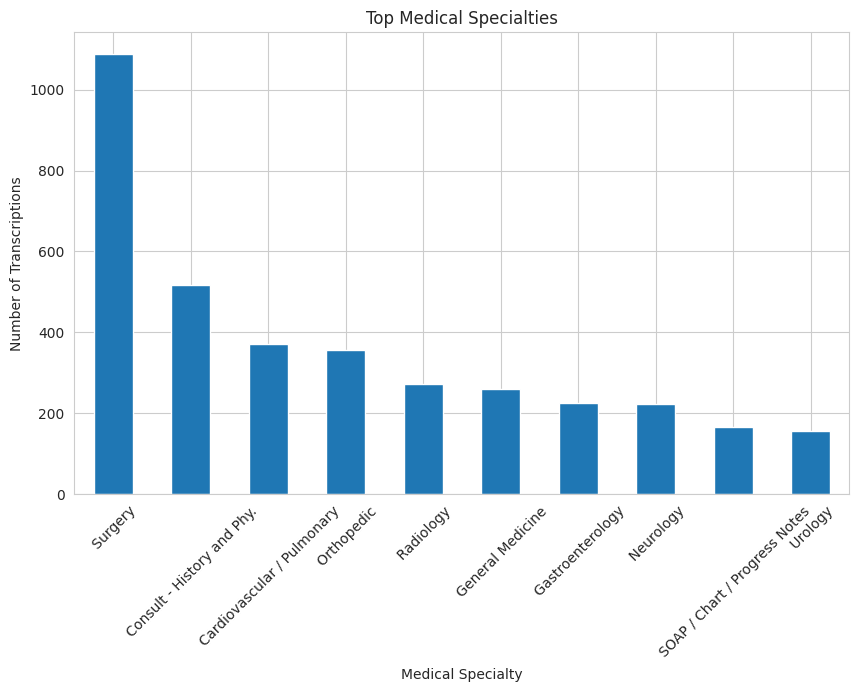

In [ ]:
plt.figure(figsize=(10,6))

text_df["medical_specialty"].value_counts().head(10).plot(kind="bar")

plt.title("Top Medical Specialties")
plt.xlabel("Medical Specialty")
plt.ylabel("Number of Transcriptions")
plt.xticks(rotation=45)
plt.show()

In [ ]:
text_df["text_length"] = text_df["processed_text"].str.len()

text_df["text_length"].describe()

,text_length
count,4966.000000
mean,2147.196738
std,1374.511804
min,9.000000
25%,1144.250000
50%,1893.000000
75%,2834.500000
max,12612.000000


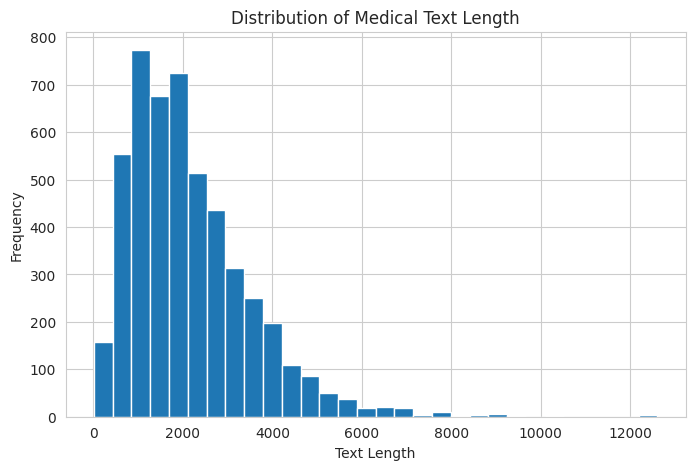

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(text_df["text_length"], bins=30)

plt.title("Distribution of Medical Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=1000,
    min_df=2,
    max_df=0.95
)

X_text = vectorizer.fit_transform(text_df["processed_text"])

print("TF-IDF shape:", X_text.shape)

TF-IDF shape: (4966, 1000)


In [ ]:
feature_names = vectorizer.get_feature_names_out()

print(feature_names[:50])


['abc' 'abcd' 'abdomen' 'abdominal' 'able' 'abnormal' 'abnormalities'
 'abscess' 'abuse' 'achieved' 'across' 'active' 'activities' 'activity'
 'actually' 'acute' 'addition' 'additional' 'adenopathy' 'adequate'
 'adhesions' 'administered' 'admission' 'admitted' 'advanced' 'age' 'ago'
 'air' 'alcohol' 'alert' 'allergies' 'along' 'also' 'alternatives'
 'although' 'amount' 'anastomosis' 'anemia' 'anesthesia' 'anesthetic'
 'ankle' 'another' 'anterior' 'anteriorly' 'antibiotic' 'antibiotics'
 'aorta' 'aortic' 'apparent' 'apparently']


In [ ]:
!pip -q install kagglehub tensorflow

In [ ]:
import kagglehub

xray_path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

print(xray_path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
/kaggle/input/chest-xray-pneumonia


In [ ]:
for root, dirs, files in os.walk(xray_path):
    print(root, len(files))
    if len(files) > 0:
        break

/kaggle/input/chest-xray-pneumonia 0
/kaggle/input/chest-xray-pneumonia/chest_xray 0
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray 1


In [ ]:
train_path = os.path.join(xray_path, "chest_xray", "train")

normal_path = os.path.join(train_path, "NORMAL")
pneumonia_path = os.path.join(train_path, "PNEUMONIA")

normal_count = len(os.listdir(normal_path))
pneumonia_count = len(os.listdir(pneumonia_path))

print("Normal images:", normal_count)
print("Pneumonia images:", pneumonia_count)


Normal images: 1341
Pneumonia images: 3875


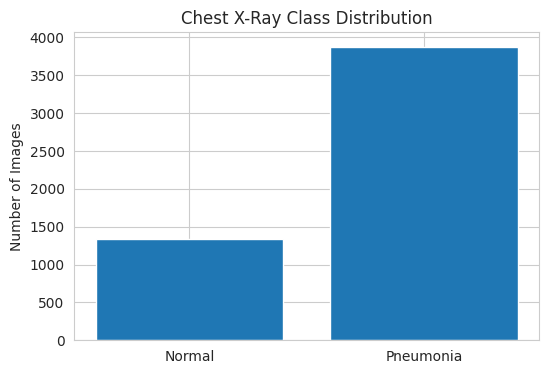

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(
    ["Normal", "Pneumonia"],
    [normal_count, pneumonia_count]
)

plt.title("Chest X-Ray Class Distribution")
plt.ylabel("Number of Images")
plt.show()

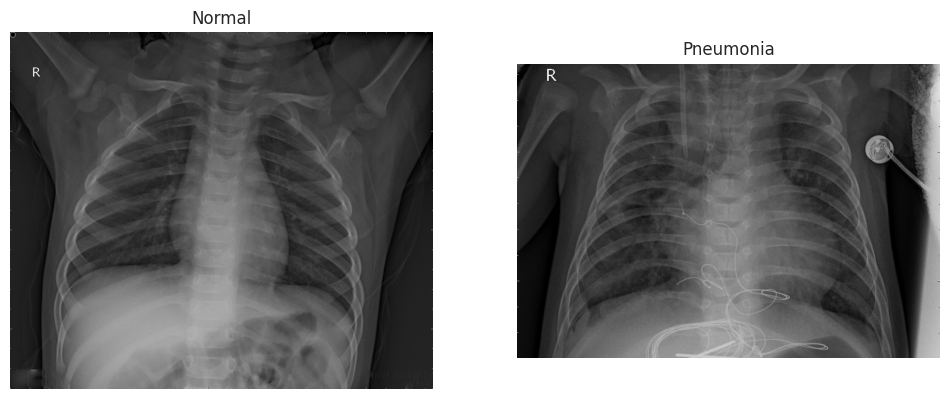

In [ ]:
from PIL import Image

normal_image = os.path.join(
    normal_path,
    os.listdir(normal_path)[0]
)

pneumonia_image = os.path.join(
    pneumonia_path,
    os.listdir(pneumonia_path)[0]
)

img1 = Image.open(normal_image)
img2 = Image.open(pneumonia_image)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img1, cmap="gray")
plt.title("Normal")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2, cmap="gray")
plt.title("Pneumonia")
plt.axis("off")

plt.show()

In [ ]:
print("Normal image size:", img1.size)
print("Pneumonia image size:", img2.size)

Normal image size: (1336, 1128)
Pneumonia image size: (1024, 712)


In [ ]:
image_size = (224, 224)

image = Image.open(normal_image).convert("L")
image = image.resize(image_size)

image_array = np.array(image)

image_array = image_array / 255.0

print("Shape:", image_array.shape)
print("Minimum:", image_array.min())
print("Maximum:", image_array.max())

Shape: (224, 224)
Minimum: 0.0
Maximum: 0.7176470588235294


In [ ]:
image_tensor = np.expand_dims(image_array, axis=(0, -1))

print("Tensor shape:", image_tensor.shape)

Tensor shape: (1, 224, 224, 1)


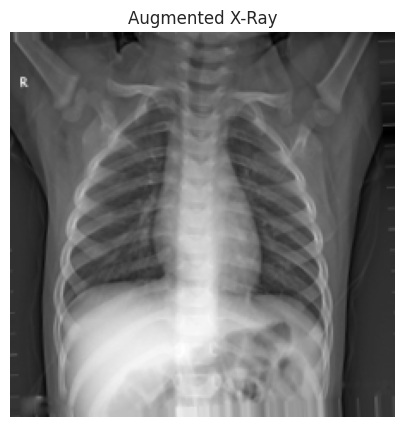

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)

batch = np.expand_dims(image_array, axis=(0, -1))

augmented = datagen.flow(
    batch,
    batch_size=1
)

augmented_image = next(augmented)[0].squeeze()

plt.figure(figsize=(5,5))

plt.imshow(augmented_image, cmap="gray")
plt.title("Augmented X-Ray")
plt.axis("off")

plt.show()

In [ ]:
!pip -q install wfdb

In [ ]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt

In [ ]:
record = wfdb.rdrecord(
    "100",
    pn_dir="mitdb"
)

print("Signal shape:", record.p_signal.shape)
print("Sampling frequency:", record.fs)
print("Signal names:", record.sig_name)

Signal shape: (650000, 2)
Sampling frequency: 360
Signal names: ['MLII', 'V5']


In [ ]:
ecg = record.p_signal[:, 0]

print("Number of samples:", len(ecg))

Number of samples: 650000


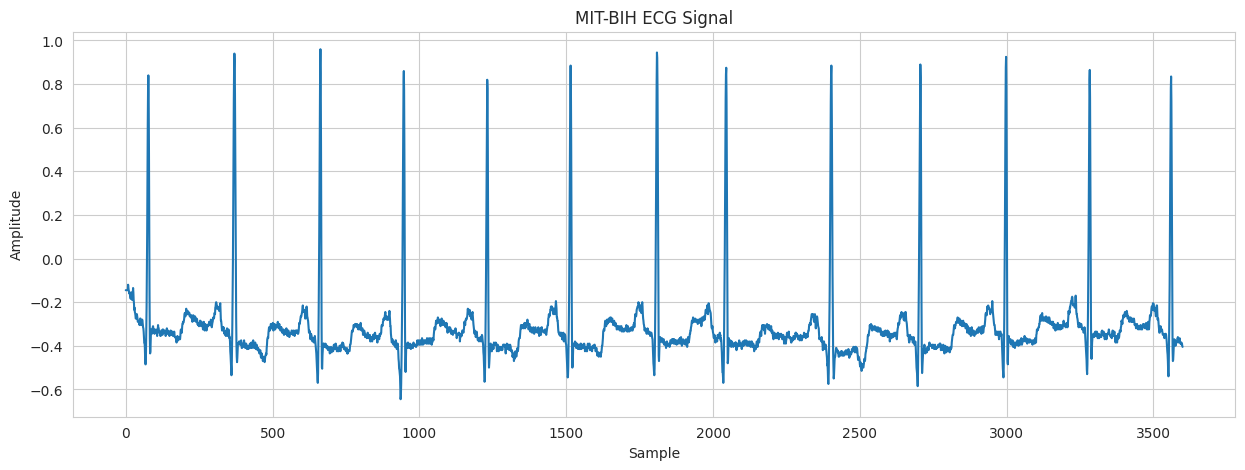

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(ecg[:3600])

plt.title("MIT-BIH ECG Signal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

In [ ]:
print("Mean:", np.mean(ecg))
print("Standard deviation:", np.std(ecg))
print("Minimum:", np.min(ecg))
print("Maximum:", np.max(ecg))


Mean: -0.3062989769230769
Standard deviation: 0.19319954213721688
Minimum: -2.715
Maximum: 1.435


In [ ]:
fs = record.fs

low_cutoff = 0.5
high_cutoff = 40

b, a = butter(
    4,
    [low_cutoff, high_cutoff],
    btype="bandpass",
    fs=fs
)

filtered_ecg = filtfilt(
    b,
    a,
    ecg
)

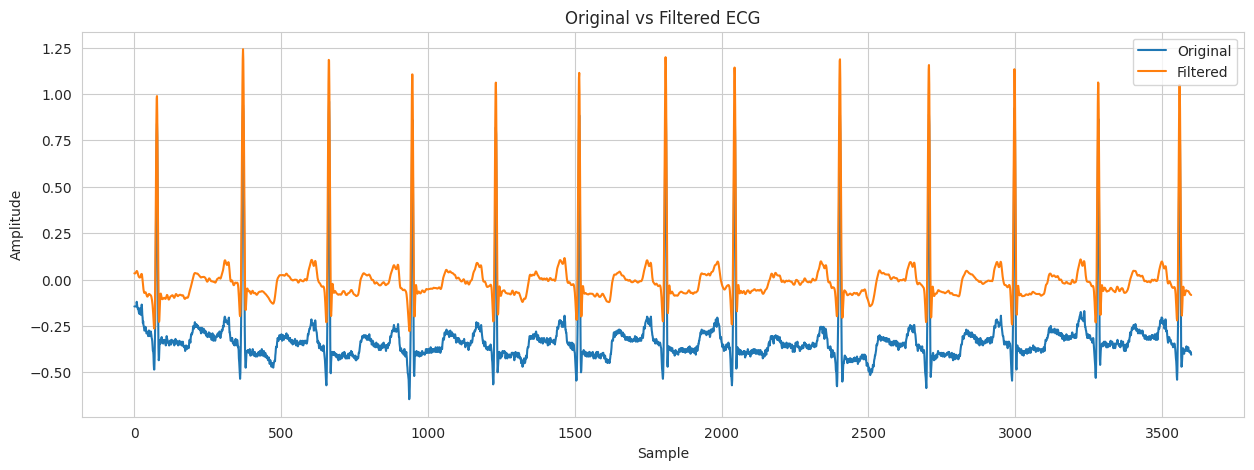

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(ecg[:3600], label="Original")
plt.plot(filtered_ecg[:3600], label="Filtered")

plt.title("Original vs Filtered ECG")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

In [ ]:
normalized_ecg = (
    filtered_ecg - np.mean(filtered_ecg)
) / np.std(filtered_ecg)

print("Mean:", np.mean(normalized_ecg))
print("Standard deviation:", np.std(normalized_ecg))

Mean: 4.9628677236166995e-18
Standard deviation: 0.9999999999999998


In [ ]:
window_size = int(5 * fs)

windows = []

for start in range(0, len(normalized_ecg) - window_size, window_size):
    window = normalized_ecg[start:start + window_size]
    windows.append(window)

windows = np.array(windows)

print("Window shape:", windows.shape)

Window shape: (361, 1800)


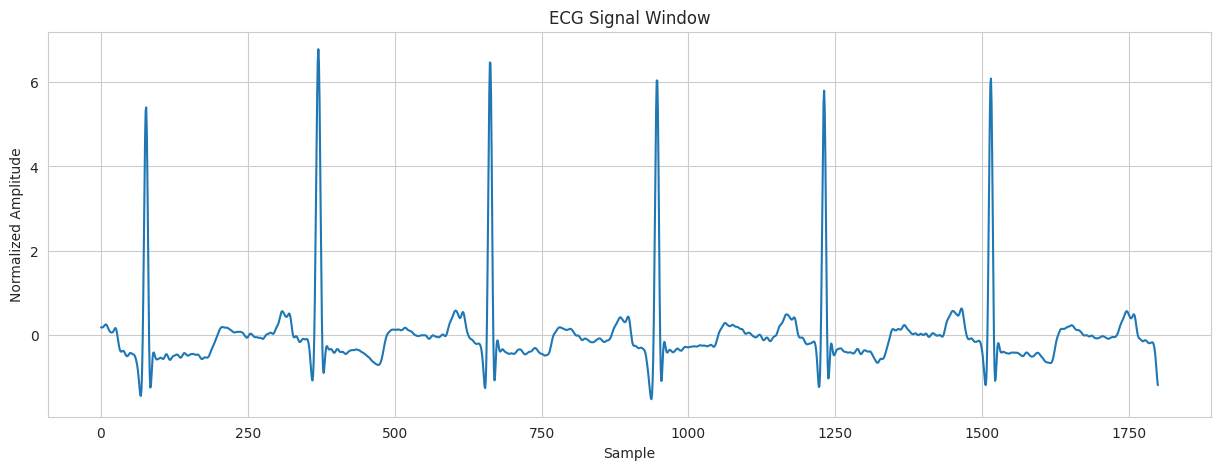

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(windows[0])

plt.title("ECG Signal Window")
plt.xlabel("Sample")
plt.ylabel("Normalized Amplitude")

plt.show()

In [ ]:
signal_features = pd.DataFrame({
    "mean": np.mean(windows, axis=1),
    "std": np.std(windows, axis=1),
    "min": np.min(windows, axis=1),
    "max": np.max(windows, axis=1),
    "median": np.median(windows, axis=1)
})

signal_features.head()

,mean,std,min,max,median
0,-0.017559,0.872081,-1.522750,6.779481,-0.096622
1,0.015614,0.932314,-1.324667,6.544627,-0.107840
2,-0.005751,0.863053,-1.401063,6.384442,-0.095221
3,-0.010556,0.920245,-1.342908,6.874545,-0.135705
4,0.000219,0.929163,-1.429475,7.192523,-0.113103


In [ ]:
signal_features.describe()


,mean,std,min,max,median
count,361.000000,361.000000,361.000000,361.000000,361.000000
mean,-0.000113,0.994977,-1.495212,7.438987,-0.123077
std,0.010571,0.090304,0.644812,0.692235,0.031969
min,-0.030602,0.807624,-13.434176,5.815303,-0.234566
25%,-0.006987,0.929596,-1.505278,6.968090,-0.141357
50%,0.000273,0.998425,-1.446435,7.477852,-0.122186
75%,0.006552,1.052946,-1.389300,7.886887,-0.102842
max,0.032029,1.757324,-1.232417,9.246860,-0.041146


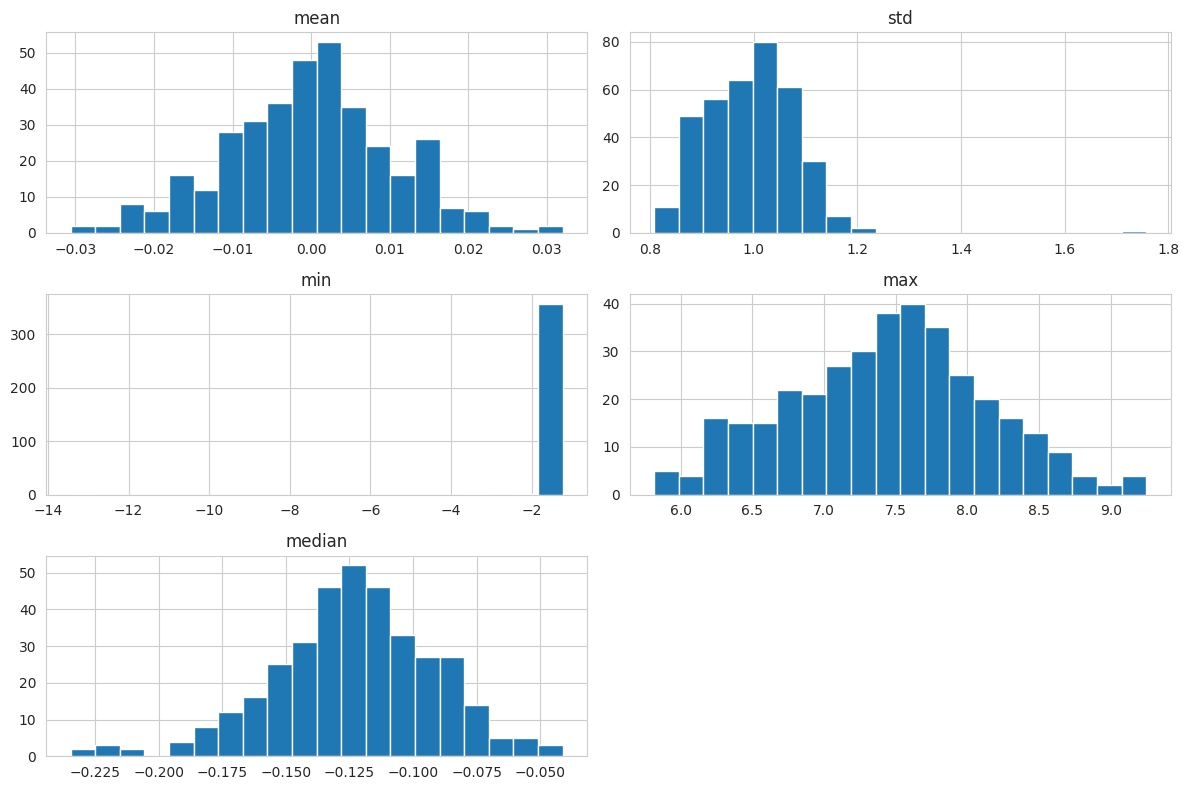

In [ ]:
signal_features.hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()
plt.show()

In [ ]:
summary = pd.DataFrame({
    "Modality": [
        "Tabular",
        "Textual",
        "Image",
        "Signal"
    ],
    "Dataset": [
        "Pima Indians Diabetes",
        "MTSamples Medical Transcriptions",
        "Chest X-Ray Pneumonia",
        "MIT-BIH Arrhythmia"
    ],
    "Preprocessing": [
        "Missing-value handling, scaling",
        "Cleaning, tokenization, stopword removal",
        "Resizing, normalization, augmentation",
        "Filtering, normalization, windowing"
    ],
    "Feature Processing": [
        "Feature engineering and selection",
        "TF-IDF feature extraction",
        "Image tensors",
        "Statistical signal features"
    ]
})

summary

,Modality,Dataset,Preprocessing,Feature Processing
0,Tabular,Pima Indians Diabetes,"Missing-value handling, scaling",Feature engineering and selection
1,Textual,MTSamples Medical Transcriptions,"Cleaning, tokenization, stopword removal",TF-IDF feature extraction
2,Image,Chest X-Ray Pneumonia,"Resizing, normalization, augmentation",Image tensors
3,Signal,MIT-BIH Arrhythmia,"Filtering, normalization, windowing",Statistical signal features
